# Hospital Performance Analytics: KPI Intelligence Report
### Lowell General Hospital | Jan 2020 – Dec 2024 | 60 Months of Data

---

## Business Context

Lowell General Hospital tracks three operational KPIs that directly affect patient safety, regulatory standing, and revenue. This notebook delivers an end-to-end analytical workup of those KPIs: trend analysis, benchmark comparison, correlation modelling, seasonal decomposition, and actionable recommendations for the nursing leadership team.

**The three KPIs under review:**

| KPI | Definition | Industry Benchmark |
|---|---|---|
| **Bed Occupancy Rate** | % of licensed beds occupied per day (avg monthly) | ~85% NHS / US average |
| **Unassisted Fall Rate** | Falls with no staff present per 1,000 patient days | ≤ 2.3 (NDNQI benchmark) |
| **Staff Responsiveness Score** | % of patients answering "Always" on 2 HCAHPS questions | ≥ 65% (national benchmark) |

**Key finding up front:** The hospital is running at a critically high occupancy rate (avg 96.2%), which is driving both a worsening fall rate and a depressed responsiveness score. The relationship is statistically significant (p < 0.001). The data supports a clear, actionable recommendation around capacity management.


## 1. Setup and Configuration

In [7]:
# ── File path setup ────────────────────────────────────────────────────────
# Place 2_RAW_DATA.xlsx in the same folder as this notebook before running.
# All output charts will also be saved to that same directory.
import os
print('Working directory:', os.getcwd())
print('Files found:', [f for f in os.listdir('.') if f.endswith(('.xlsx','.csv','.ipynb'))])

Working directory: /Users/shahbaz/Desktop/project
Files found: ['Hospital_KPI_Analysis_FIXED.ipynb', '2.RAW_DATA.xlsx']


In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, linregress

# ── Style configuration ───────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': '#F8F9FA',
    'axes.edgecolor': '#CCCCCC',
    'axes.grid': True,
    'grid.color': '#E0E0E0',
    'grid.linestyle': '--',
    'grid.linewidth': 0.7,
    'font.family': 'DejaVu Sans',
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 10,
    'figure.titlesize': 15,
    'figure.titleweight': 'bold'
})

# ── Colour palette ────────────────────────────────────────────────────────
PALETTE = {
    'occupancy':     '#2563EB',   # blue
    'fall_rate':     '#DC2626',   # red
    'responsiveness':'#16A34A',   # green
    'benchmark':     '#F59E0B',   # amber
    'warning':       '#FCA5A5',   # light red
    'good':          '#BBF7D0',   # light green
    'neutral':       '#DBEAFE',   # light blue
    'text_dark':     '#1F2937'
}

BENCHMARKS = {
    'occupancy': 85.0,         # NHS / US ~66-85%, we use 85 as operational target
    'fall_rate': 2.3,          # NDNQI 50th percentile
    'responsiveness': 65.0     # HCAHPS national benchmark
}

print("Setup complete. Libraries loaded.")


Setup complete. Libraries loaded.


## 2. Data Loading and Quality Audit

In [9]:
# ── Load raw data ────────────────────────────────────────────────────────────
# Ensure 2_RAW_DATA.xlsx is in the same directory as this notebook
raw = pd.read_excel('2.RAW_DATA.xlsx', sheet_name='Case Study Dataset', header=None)
raw.columns = raw.iloc[1]
raw = raw.iloc[2:].copy()
raw = raw.dropna(subset=['Month'])

df = raw[['Month',
          'Average Licensed Bed  Occupancy Rate',
          'Unassisted Fall Rate per 1,000 Patient Days',
          'Staff Responsiveness Domain Top Box Score']].copy()

df.columns = ['month', 'occupancy', 'fall_rate', 'responsiveness']

df['month']         = pd.to_datetime(df['month'])
df['occupancy']     = pd.to_numeric(df['occupancy']) * 100   # convert to %
df['fall_rate']     = pd.to_numeric(df['fall_rate'])
df['responsiveness']= pd.to_numeric(df['responsiveness'])

# ── Derived time columns ─────────────────────────────────────────────────────
df['year']       = df['month'].dt.year
df['month_num']  = df['month'].dt.month
df['month_name'] = df['month'].dt.month_name()
df['quarter']    = df['month'].dt.quarter
df               = df.sort_values('month').reset_index(drop=True)

print(f"Dataset loaded: {df.shape[0]} rows x {df.shape[1]} columns")
print(f"Date range   : {df['month'].min().strftime('%b %Y')} to {df['month'].max().strftime('%b %Y')}")


Dataset loaded: 60 rows x 8 columns
Date range   : Jan 2020 to Dec 2024


In [10]:
# ── Data quality report ───────────────────────────────────────────────────────
print("=" * 55)
print("  DATA QUALITY REPORT")
print("=" * 55)

for col in ['occupancy', 'fall_rate', 'responsiveness']:
    nulls = df[col].isna().sum()
    dupes = df['month'].duplicated().sum()
    print(f"  {col:20s} | nulls: {nulls} | dtype: {df[col].dtype}")

print(f"\n  Duplicate month entries : {df['month'].duplicated().sum()}")
print(f"  Total observations      : {len(df)}")
print(f"  Expected (5yr monthly)  : 60")
print(f"  Coverage                : {'Complete' if len(df)==60 else 'Gaps detected'}")
print("=" * 55)


  DATA QUALITY REPORT
  occupancy            | nulls: 0 | dtype: float64
  fall_rate            | nulls: 0 | dtype: float64
  responsiveness       | nulls: 0 | dtype: float64

  Duplicate month entries : 0
  Total observations      : 60
  Expected (5yr monthly)  : 60
  Coverage                : Complete


In [11]:
# ── Summary statistics with business context ─────────────────────────────────
stats = df[['occupancy', 'fall_rate', 'responsiveness']].describe().round(2)

benchmarks_row = pd.DataFrame(
    [[BENCHMARKS['occupancy'], BENCHMARKS['fall_rate'], BENCHMARKS['responsiveness']]],
    columns=['occupancy', 'fall_rate', 'responsiveness'],
    index=['benchmark']
)

print("\nDescriptive Statistics")
print("-" * 50)
print(stats)
print(benchmarks_row)
print("\nKey business gaps vs benchmark:")
print(f"  Occupancy      : {df['occupancy'].mean():.1f}% vs {BENCHMARKS['occupancy']}% target  (+{df['occupancy'].mean()-BENCHMARKS['occupancy']:.1f}pp ABOVE)")
print(f"  Fall Rate      : {df['fall_rate'].mean():.2f}  vs {BENCHMARKS['fall_rate']} benchmark (+{df['fall_rate'].mean()-BENCHMARKS['fall_rate']:.2f} ABOVE)")
print(f"  Responsiveness : {df['responsiveness'].mean():.1f}% vs {BENCHMARKS['responsiveness']}% benchmark ({df['responsiveness'].mean()-BENCHMARKS['responsiveness']:.1f}pp BELOW)")



Descriptive Statistics
--------------------------------------------------
       occupancy  fall_rate  responsiveness
count      60.00      60.00           60.00
mean       96.22       2.61           63.09
std         2.84       0.50            4.15
min        81.00       1.03           53.31
25%        95.00       2.31           60.34
50%        96.00       2.59           63.62
75%        98.00       3.03           65.99
max       101.00       3.41           72.75
           occupancy  fall_rate  responsiveness
benchmark       85.0        2.3            65.0

Key business gaps vs benchmark:
  Occupancy      : 96.2% vs 85.0% target  (+11.2pp ABOVE)
  Fall Rate      : 2.61  vs 2.3 benchmark (+0.31 ABOVE)
  Responsiveness : 63.1% vs 65.0% benchmark (-1.9pp BELOW)


## 3. KPI Performance Dashboard

A single-view summary of all three KPIs against their benchmarks over the full 5-year window.


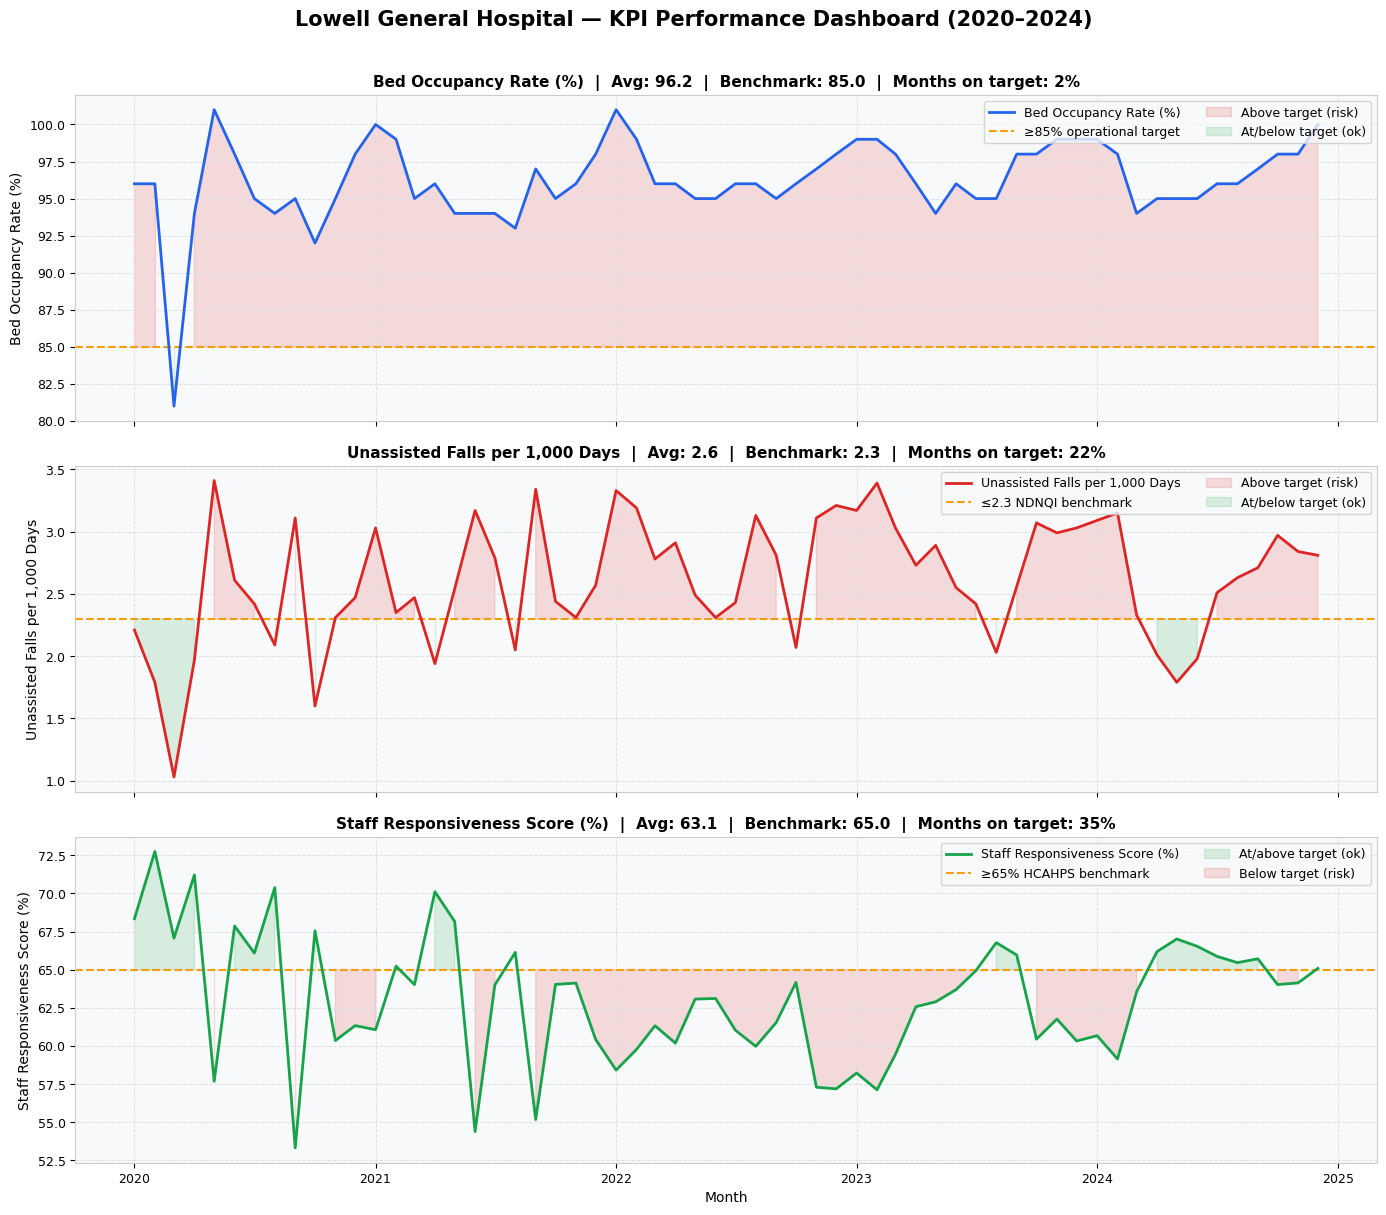

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Lowell General Hospital — KPI Performance Dashboard (2020–2024)', y=1.01)

kpi_config = [
    ('occupancy',      'Bed Occupancy Rate (%)',            PALETTE['occupancy'],      '≥85% operational target',  'upper', True),
    ('fall_rate',      'Unassisted Falls per 1,000 Days',   PALETTE['fall_rate'],      '≤2.3 NDNQI benchmark',     'upper', True),
    ('responsiveness', 'Staff Responsiveness Score (%)',    PALETTE['responsiveness'], '≥65% HCAHPS benchmark',    'lower', False),
]

for ax, (col, label, color, bench_label, fill_side, above_bad) in zip(axes, kpi_config):
    bmark = BENCHMARKS[col]
    ax.plot(df['month'], df[col], color=color, linewidth=2, zorder=3, label=label)
    ax.axhline(bmark, color=PALETTE['benchmark'], linewidth=1.5, linestyle='--', label=bench_label, zorder=2)

    ymin = ax.get_ylim()[0]
    ymax = ax.get_ylim()[1]
    if above_bad:
        ax.fill_between(df['month'], bmark, df[col],
                        where=(df[col] > bmark), alpha=0.15, color=PALETTE['fall_rate'], label='Above target (risk)')
        ax.fill_between(df['month'], bmark, df[col],
                        where=(df[col] <= bmark), alpha=0.15, color=PALETTE['responsiveness'], label='At/below target (ok)')
    else:
        ax.fill_between(df['month'], bmark, df[col],
                        where=(df[col] >= bmark), alpha=0.15, color=PALETTE['responsiveness'], label='At/above target (ok)')
        ax.fill_between(df['month'], bmark, df[col],
                        where=(df[col] < bmark), alpha=0.15, color=PALETTE['fall_rate'], label='Below target (risk)')

    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=2)

    pct_ok = (df[col] <= bmark).mean() * 100 if above_bad else (df[col] >= bmark).mean() * 100
    ax.set_title(f'{label}  |  Avg: {df[col].mean():.1f}  |  Benchmark: {bmark}  |  Months on target: {pct_ok:.0f}%', fontsize=11)

axes[-1].set_xlabel('Month', fontsize=10)
plt.tight_layout()
plt.savefig('01_kpi_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Benchmark Scorecard

How often does each KPI meet its benchmark? A quick pass-rate breakdown recruiters and clinicians can act on.


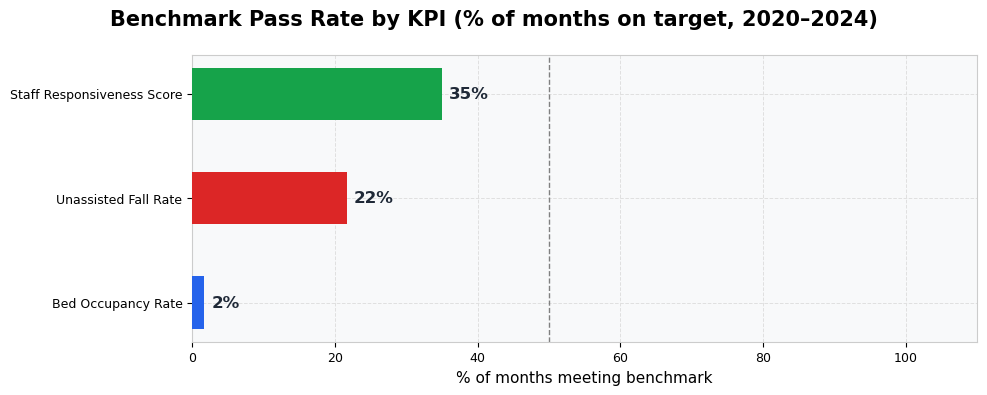


Pass-rate summary:
  Bed Occupancy Rate                 : 2% [FAIL]
  Unassisted Fall Rate               : 22% [FAIL]
  Staff Responsiveness Score         : 35% [FAIL]


In [13]:
pass_rates = {
    'Bed Occupancy Rate':        (df['occupancy']      <= BENCHMARKS['occupancy']).mean() * 100,
    'Unassisted Fall Rate':      (df['fall_rate']       <= BENCHMARKS['fall_rate']).mean() * 100,
    'Staff Responsiveness Score':(df['responsiveness'] >= BENCHMARKS['responsiveness']).mean() * 100,
}

fig, ax = plt.subplots(figsize=(10, 4))
fig.suptitle('Benchmark Pass Rate by KPI (% of months on target, 2020–2024)')

colors_bar = [PALETTE['occupancy'], PALETTE['fall_rate'], PALETTE['responsiveness']]
bars = ax.barh(list(pass_rates.keys()), list(pass_rates.values()),
               color=colors_bar, height=0.5, zorder=3)

ax.axvline(50, color='grey', linestyle='--', linewidth=1)
ax.set_xlim(0, 110)
ax.set_xlabel('% of months meeting benchmark')

for bar, val in zip(bars, pass_rates.values()):
    color = PALETTE['responsiveness'] if val >= 50 else PALETTE['fall_rate']
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2,
            f'{val:.0f}%', va='center', fontsize=12, fontweight='bold', color=PALETTE['text_dark'])

plt.tight_layout()
plt.savefig('02_benchmark_scorecard.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nPass-rate summary:")
for kpi, rate in pass_rates.items():
    status = 'PASS' if rate >= 50 else 'FAIL'
    print(f"  {kpi:35s}: {rate:.0f}% [{status}]")


## 5. Trend Analysis with 12-Month Rolling Averages

Rolling averages smooth out seasonal noise and reveal the underlying direction of each KPI.
The trend lines here answer the question leadership actually asks: *are we getting better or worse?*


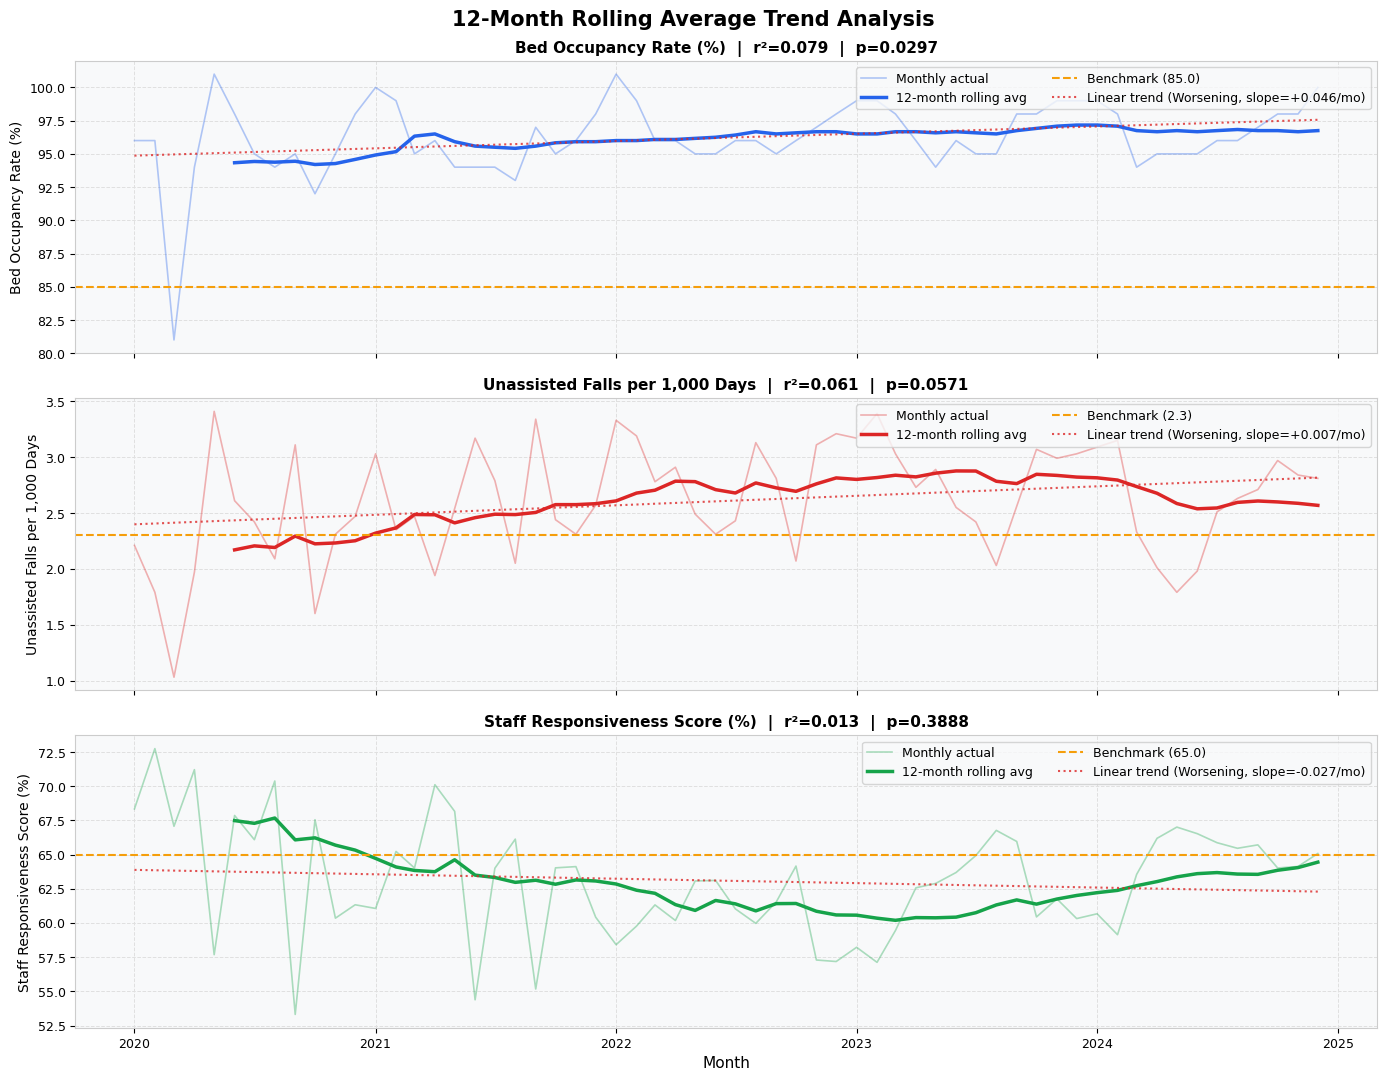

In [14]:
df['occ_roll12']  = df['occupancy'].rolling(12, min_periods=6).mean()
df['fall_roll12'] = df['fall_rate'].rolling(12, min_periods=6).mean()
df['resp_roll12'] = df['responsiveness'].rolling(12, min_periods=6).mean()

fig, axes = plt.subplots(3, 1, figsize=(14, 11), sharex=True)
fig.suptitle('12-Month Rolling Average Trend Analysis')

trend_config = [
    ('occupancy',      'occ_roll12',  'Bed Occupancy Rate (%)',           PALETTE['occupancy']),
    ('fall_rate',      'fall_roll12', 'Unassisted Falls per 1,000 Days',  PALETTE['fall_rate']),
    ('responsiveness', 'resp_roll12', 'Staff Responsiveness Score (%)',   PALETTE['responsiveness']),
]

for ax, (col, roll_col, label, color) in zip(axes, trend_config):
    bmark = BENCHMARKS[col]
    ax.plot(df['month'], df[col], color=color, alpha=0.35, linewidth=1.2, label='Monthly actual')
    ax.plot(df['month'], df[roll_col], color=color, linewidth=2.5, label='12-month rolling avg')
    ax.axhline(bmark, color=PALETTE['benchmark'], linewidth=1.5, linestyle='--', label=f'Benchmark ({bmark})')

    # linear trend
    x_num = np.arange(len(df))
    slope, intercept, r_val, p_val, _ = linregress(x_num, df[col])
    trend_line = intercept + slope * x_num
    direction = 'Improving' if (col == 'responsiveness' and slope > 0) or (col != 'responsiveness' and slope < 0) else 'Worsening'
    trend_color = PALETTE['responsiveness'] if direction == 'Improving' else PALETTE['fall_rate']
    ax.plot(df['month'], trend_line, color=trend_color, linewidth=1.5, linestyle=':', alpha=0.8,
            label=f'Linear trend ({direction}, slope={slope:+.3f}/mo)')

    ax.set_ylabel(label, fontsize=10)
    ax.legend(loc='upper right', fontsize=9, ncol=2)
    ax.set_title(f'{label}  |  r²={r_val**2:.3f}  |  p={p_val:.4f}', fontsize=11)

axes[-1].set_xlabel('Month')
plt.tight_layout()
plt.savefig('03_rolling_trends.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Year-over-Year Performance Comparison

Grouped view across all five years. Identifying which years were inflection points.


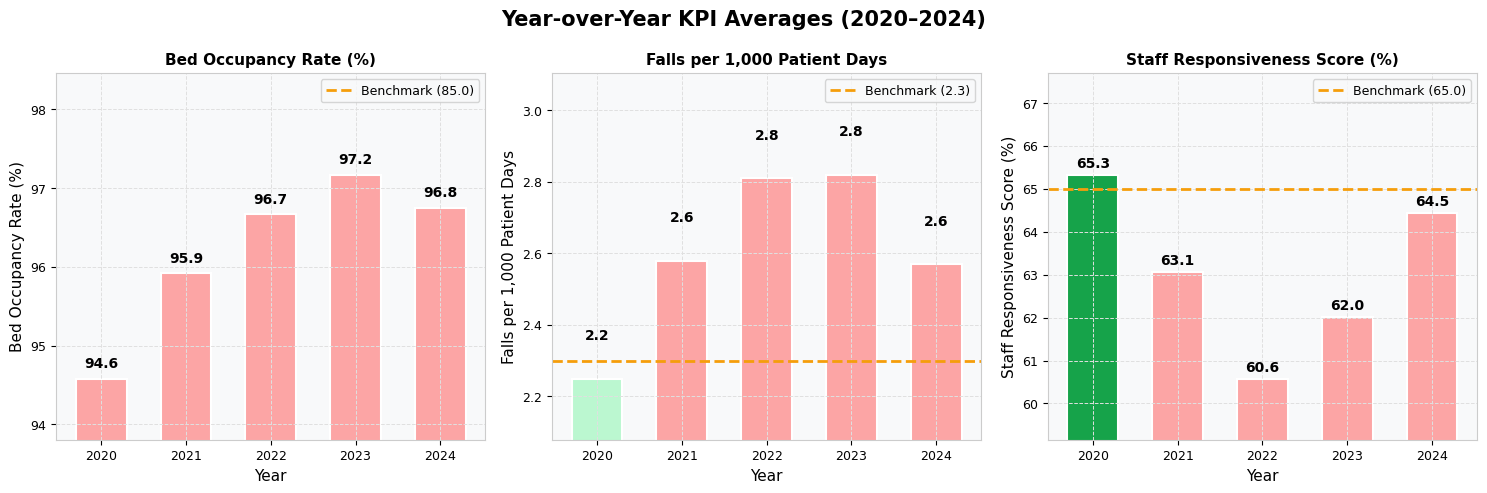

Year-over-Year averages:
      occupancy  fall_rate  responsiveness
year                                      
2020      94.58       2.25           65.33
2021      95.92       2.58           63.07
2022      96.67       2.81           60.58
2023      97.17       2.82           62.01
2024      96.75       2.57           64.45


In [15]:
yearly = df.groupby('year')[['occupancy', 'fall_rate', 'responsiveness']].mean().round(2)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Year-over-Year KPI Averages (2020–2024)')

yoy_config = [
    ('occupancy',      'Bed Occupancy Rate (%)',           PALETTE['occupancy'],     BENCHMARKS['occupancy'],     False),
    ('fall_rate',      'Falls per 1,000 Patient Days',     PALETTE['fall_rate'],     BENCHMARKS['fall_rate'],     False),
    ('responsiveness', 'Staff Responsiveness Score (%)',   PALETTE['responsiveness'],BENCHMARKS['responsiveness'],True),
]

for ax, (col, label, color, bmark, above_good) in zip(axes, yoy_config):
    vals = yearly[col].values
    bar_colors = []
    for v in vals:
        if above_good:
            bar_colors.append(PALETTE['responsiveness'] if v >= bmark else PALETTE['warning'])
        else:
            bar_colors.append(PALETTE['good'] if v <= bmark else PALETTE['warning'])

    bars = ax.bar(yearly.index, vals, color=bar_colors, edgecolor='white', linewidth=1.5, width=0.6)
    ax.axhline(bmark, color=PALETTE['benchmark'], linewidth=2, linestyle='--', label=f'Benchmark ({bmark})')

    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.1,
                f'{val:.1f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    y_range = vals.max() - vals.min()
    ax.set_ylim(vals.min() - y_range * 0.3, vals.max() + y_range * 0.5)

plt.tight_layout()
plt.savefig('04_yoy_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Year-over-Year averages:")
print(yearly.to_string())


## 7. Seasonal Patterns

Are there months that consistently underperform? Seasonality in healthcare KPIs often reflects staffing cycles, winter pressures, and discharge patterns.


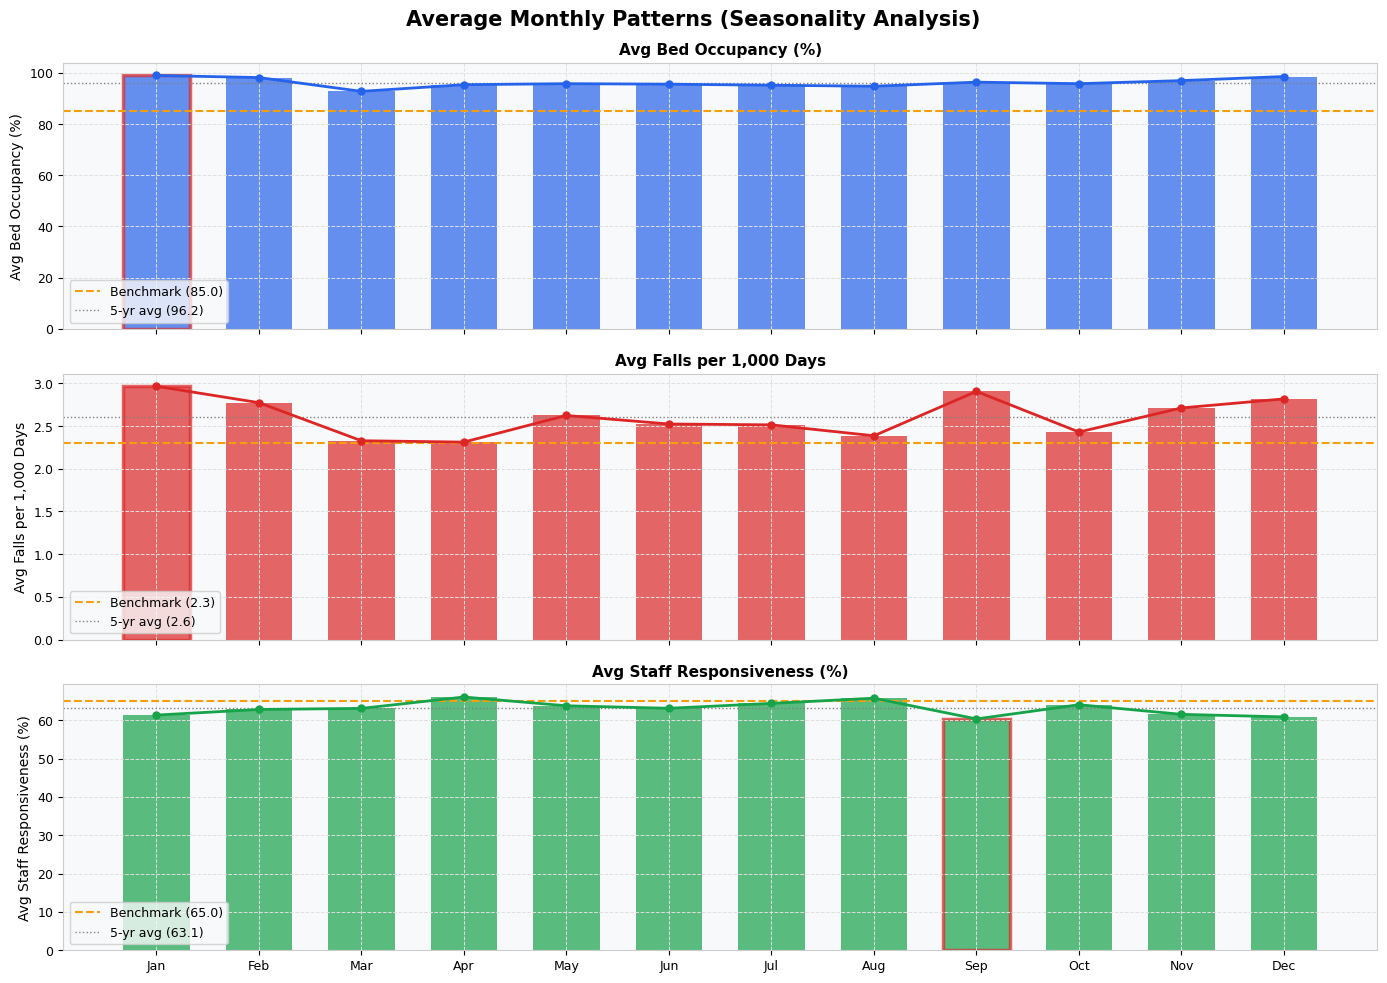


Seasonal highlights:
  Avg Bed Occupancy (%)          | Worst month: January    (99.00) | Best: March (92.80)
  Avg Falls per 1,000 Days       | Worst month: January    (2.97) | Best: April (2.31)
  Avg Staff Responsiveness (%)   | Worst month: September  (60.34) | Best: April (66.05)


In [16]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_avg = df.groupby('month_name')[['occupancy', 'fall_rate', 'responsiveness']].mean()
monthly_avg = monthly_avg.reindex(month_order)

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Average Monthly Patterns (Seasonality Analysis)')

seasonal_config = [
    ('occupancy',      'Avg Bed Occupancy (%)',           PALETTE['occupancy'],      BENCHMARKS['occupancy']),
    ('fall_rate',      'Avg Falls per 1,000 Days',        PALETTE['fall_rate'],      BENCHMARKS['fall_rate']),
    ('responsiveness', 'Avg Staff Responsiveness (%)',    PALETTE['responsiveness'], BENCHMARKS['responsiveness']),
]

for ax, (col, label, color, bmark) in zip(axes, seasonal_config):
    vals = monthly_avg[col]
    overall_mean = vals.mean()

    bars = ax.bar(range(12), vals, color=color, alpha=0.7, width=0.65)
    ax.plot(range(12), vals, 'o-', color=color, linewidth=2, markersize=5, zorder=5)
    ax.axhline(bmark, color=PALETTE['benchmark'], linewidth=1.5, linestyle='--', label=f'Benchmark ({bmark})')
    ax.axhline(overall_mean, color='grey', linewidth=1, linestyle=':', label=f'5-yr avg ({overall_mean:.1f})')

    ax.set_xticks(range(12))
    ax.set_xticklabels([m[:3] for m in month_order], fontsize=9)
    ax.set_ylabel(label, fontsize=10)
    ax.legend(fontsize=9)
    ax.set_title(label, fontsize=11)

    worst_idx = vals.values.argmax() if col != 'responsiveness' else vals.values.argmin()
    ax.get_children()[worst_idx].set_edgecolor(PALETTE['fall_rate'])
    ax.get_children()[worst_idx].set_linewidth(2.5)

plt.tight_layout()
plt.savefig('05_seasonal_patterns.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nSeasonal highlights:")
for col, label, _, _ in seasonal_config:
    worst = monthly_avg[col].idxmax() if col != 'responsiveness' else monthly_avg[col].idxmin()
    best  = monthly_avg[col].idxmin() if col != 'responsiveness' else monthly_avg[col].idxmax()
    print(f"  {label[:30]:30s} | Worst month: {worst:10s} ({monthly_avg.loc[worst,col]:.2f}) | Best: {best} ({monthly_avg.loc[best,col]:.2f})")


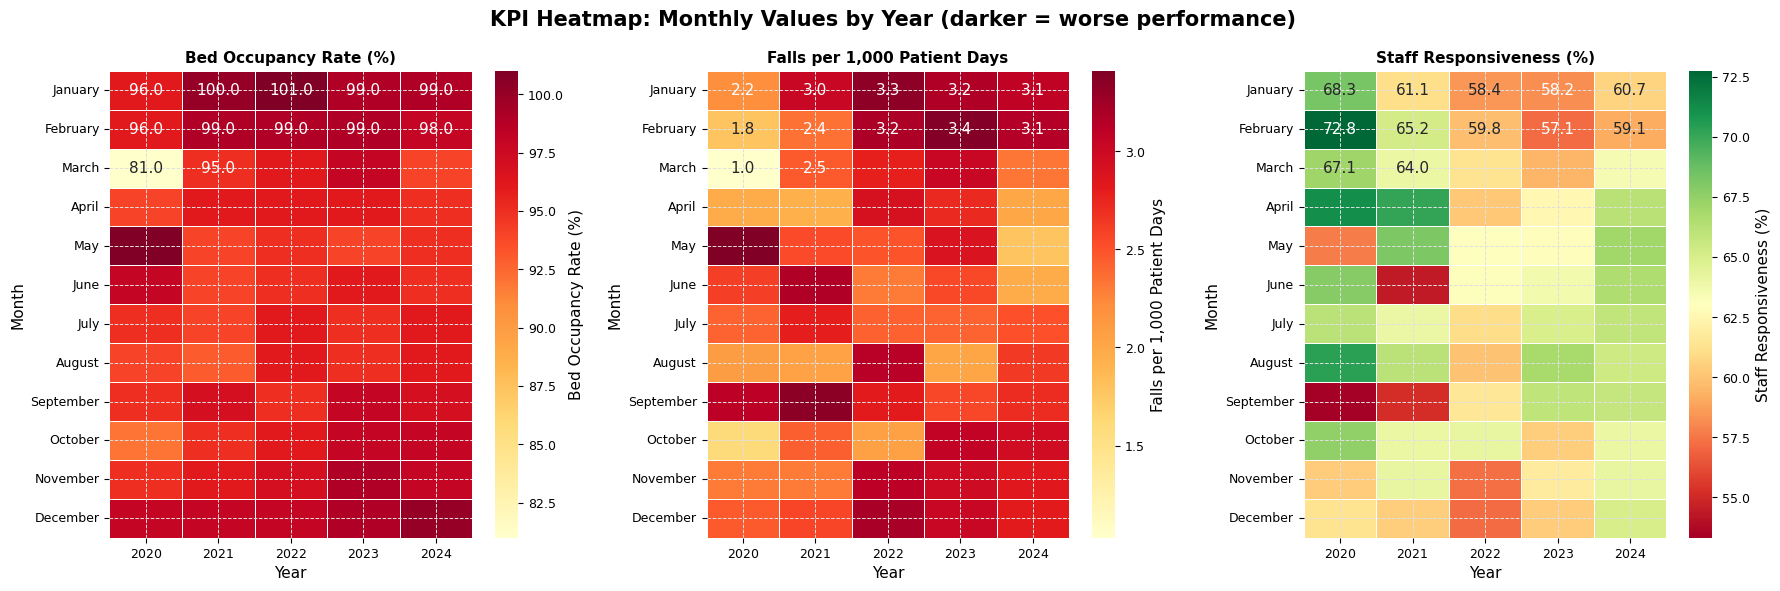

In [17]:
# ── Heatmap: KPI values by month x year ─────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('KPI Heatmap: Monthly Values by Year (darker = worse performance)')

heatmap_config = [
    ('occupancy',      'Bed Occupancy Rate (%)',        'YlOrRd'),
    ('fall_rate',      'Falls per 1,000 Patient Days',  'YlOrRd'),
    ('responsiveness', 'Staff Responsiveness (%)',      'RdYlGn'),
]

for ax, (col, label, cmap) in zip(axes, heatmap_config):
    pivot = df.pivot_table(index='month_name', columns='year', values=col, aggfunc='mean')
    pivot = pivot.reindex(month_order)

    sns.heatmap(pivot, ax=ax, cmap=cmap, annot=True, fmt='.1f',
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': label})
    ax.set_title(label, fontsize=11)
    ax.set_xlabel('Year')
    ax.set_ylabel('Month')

plt.tight_layout()
plt.savefig('06_kpi_heatmaps.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Correlation and Regression Analysis

The core analytical question: are the three KPIs statistically related, and if so, how strongly? This section provides both Pearson and Spearman coefficients with p-values, scatter plots with regression lines, and an interpretation table for the clinical audience.


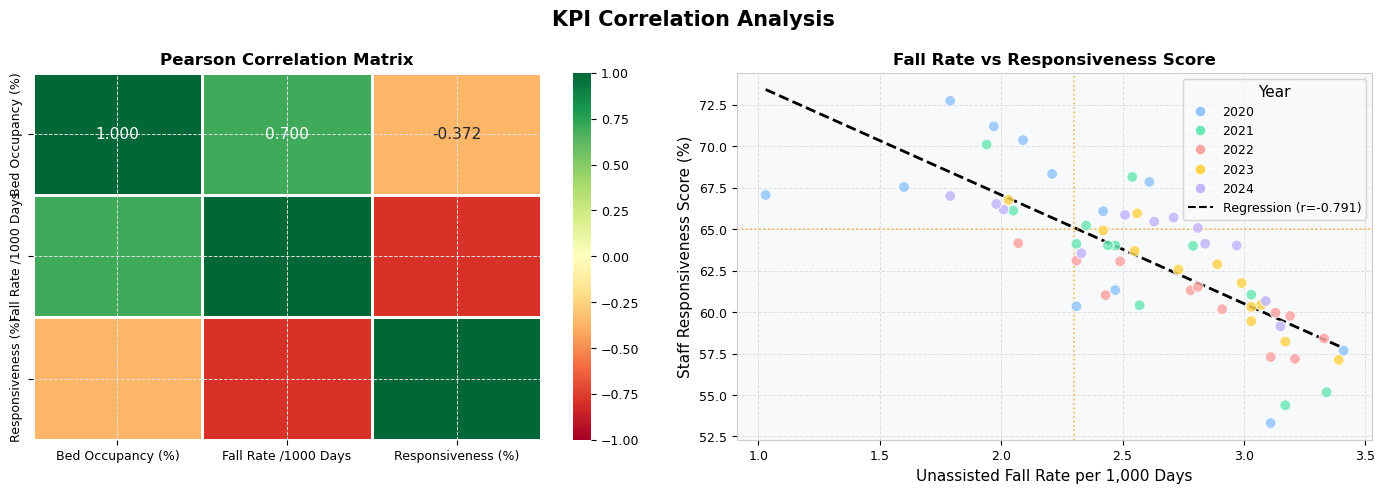

In [18]:
kpi_cols = ['occupancy', 'fall_rate', 'responsiveness']
kpi_labels = {
    'occupancy':      'Bed Occupancy (%)',
    'fall_rate':      'Fall Rate /1000 Days',
    'responsiveness': 'Responsiveness (%)'
}

# ── Pearson correlation matrix ───────────────────────────────────────────────
corr_matrix = df[kpi_cols].corr()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('KPI Correlation Analysis')

# Heatmap
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask, k=1)] = False

sns.heatmap(corr_matrix, ax=axes[0], annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-1, vmax=1, linewidths=1, linecolor='white',
            xticklabels=[kpi_labels[c] for c in kpi_cols],
            yticklabels=[kpi_labels[c] for c in kpi_cols])
axes[0].set_title('Pearson Correlation Matrix', fontsize=12)

# Pair scatter: fall_rate vs responsiveness (strongest relationship)
x = df['fall_rate']
y = df['responsiveness']
slope, intercept, r_val, p_val, se = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = slope * x_line + intercept

scatter_colors = df['year'].map({2020:'#93C5FD',2021:'#6EE7B7',2022:'#FCA5A5',2023:'#FCD34D',2024:'#C4B5FD'})
axes[1].scatter(x, y, c=scatter_colors, s=60, alpha=0.85, edgecolors='white', linewidth=0.7, zorder=3)
axes[1].plot(x_line, y_line, color='black', linewidth=2, linestyle='--', label=f'Regression (r={r_val:.3f}, p<0.001)')
axes[1].axvline(BENCHMARKS['fall_rate'], color=PALETTE['benchmark'], linewidth=1.2, linestyle=':', alpha=0.7)
axes[1].axhline(BENCHMARKS['responsiveness'], color=PALETTE['benchmark'], linewidth=1.2, linestyle=':', alpha=0.7)
axes[1].set_xlabel('Unassisted Fall Rate per 1,000 Days', fontsize=11)
axes[1].set_ylabel('Staff Responsiveness Score (%)', fontsize=11)
axes[1].set_title('Fall Rate vs Responsiveness Score', fontsize=12)
axes[1].legend(fontsize=10)

# Year legend
from matplotlib.lines import Line2D
year_colors = {'2020':'#93C5FD','2021':'#6EE7B7','2022':'#FCA5A5','2023':'#FCD34D','2024':'#C4B5FD'}
handles = [Line2D([0],[0], marker='o', color='w', markerfacecolor=c, markersize=8, label=yr)
           for yr, c in year_colors.items()]
axes[1].legend(handles=handles + [Line2D([0],[0], linestyle='--', color='black', label=f'Regression (r={r_val:.3f})')],
               fontsize=9, title='Year')

plt.tight_layout()
plt.savefig('07_correlation_analysis.png', dpi=150, bbox_inches='tight')
plt.show()


In [19]:
# ── Full statistical correlation table ───────────────────────────────────────
pairs = [
    ('occupancy',      'fall_rate'),
    ('occupancy',      'responsiveness'),
    ('fall_rate',      'responsiveness'),
]

print("=" * 78)
print(f"  {'KPI Pair':<38} {'Pearson r':>10} {'p-value':>10} {'Spearman r':>10} {'Strength'}")
print("=" * 78)

def corr_strength(r):
    r = abs(r)
    if r >= 0.8: return 'Very Strong'
    if r >= 0.6: return 'Strong'
    if r >= 0.4: return 'Moderate'
    if r >= 0.2: return 'Weak'
    return 'Very Weak'

for c1, c2 in pairs:
    pr, pp = pearsonr(df[c1], df[c2])
    sr, sp = spearmanr(df[c1], df[c2])
    pair_label = f"{kpi_labels[c1]} vs {kpi_labels[c2]}"
    p_str = f'{pp:.4f}' if pp >= 0.0001 else '<0.0001'
    print(f"  {pair_label:<38} {pr:>10.3f} {p_str:>10} {sr:>10.3f}   {corr_strength(pr)}")

print("=" * 78)
print("\nInterpretation:")
print("  r > 0  = positive relationship (both KPIs move in the same direction)")
print("  r < 0  = inverse relationship (one KPI rises as the other falls)")
print("  |r| > 0.7 at p < 0.05 is considered actionable for operations")


  KPI Pair                                Pearson r    p-value Spearman r Strength
  Bed Occupancy (%) vs Fall Rate /1000 Days      0.700    <0.0001      0.619   Strong
  Bed Occupancy (%) vs Responsiveness (%)     -0.372     0.0034     -0.450   Weak
  Fall Rate /1000 Days vs Responsiveness (%)     -0.791    <0.0001     -0.836   Strong

Interpretation:
  r > 0  = positive relationship (both KPIs move in the same direction)
  r < 0  = inverse relationship (one KPI rises as the other falls)
  |r| > 0.7 at p < 0.05 is considered actionable for operations


## 9. Multi-KPI Scatter Plot Matrix

A pairwise view of all three KPIs coloured by year. Reveals how the relationship between KPIs shifted across the five-year window.


/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before opera

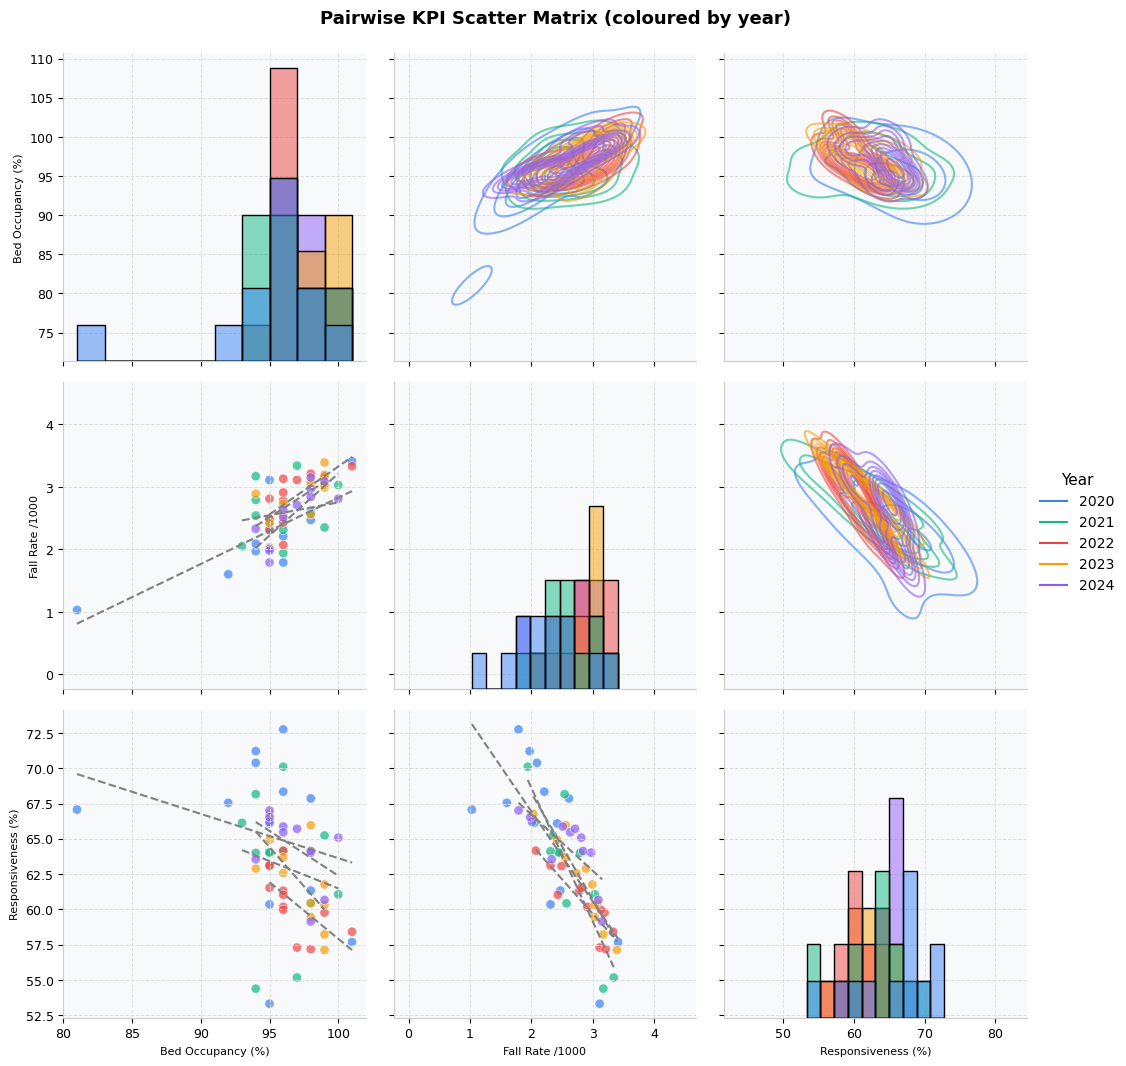

In [20]:
year_palette = {2020:'#3B82F6', 2021:'#10B981', 2022:'#EF4444', 2023:'#F59E0B', 2024:'#8B5CF6'}

g = sns.PairGrid(df[['occupancy','fall_rate','responsiveness','year']],
                 vars=['occupancy','fall_rate','responsiveness'],
                 hue='year', palette=year_palette, height=3.5)

g.map_diag(sns.histplot, alpha=0.5, bins=10)
g.map_lower(sns.regplot, scatter=False, ci=None, line_kws={'color':'grey','linewidth':1.5,'linestyle':'--'})
g.map_lower(sns.scatterplot, alpha=0.7, s=45, edgecolor='white', linewidth=0.5)
g.map_upper(sns.kdeplot, alpha=0.6, fill=False)
g.add_legend(title='Year')

axis_labels = {'occupancy':'Bed Occupancy (%)','fall_rate':'Fall Rate /1000','responsiveness':'Responsiveness (%)'}
for i, row_var in enumerate(['occupancy','fall_rate','responsiveness']):
    for j, col_var in enumerate(['occupancy','fall_rate','responsiveness']):
        g.axes[i][j].set_xlabel(axis_labels[col_var], fontsize=8)
        g.axes[i][j].set_ylabel(axis_labels[row_var], fontsize=8)

g.figure.suptitle('Pairwise KPI Scatter Matrix (coloured by year)', y=1.02, fontsize=13, fontweight='bold')
plt.savefig('08_scatter_matrix.png', dpi=150, bbox_inches='tight')
plt.show()


## 10. Distributional Analysis: Box Plots by Year

Box plots reveal the spread, median, and outliers for each KPI per year. A shrinking box or rising median in the right direction signals operational improvement.


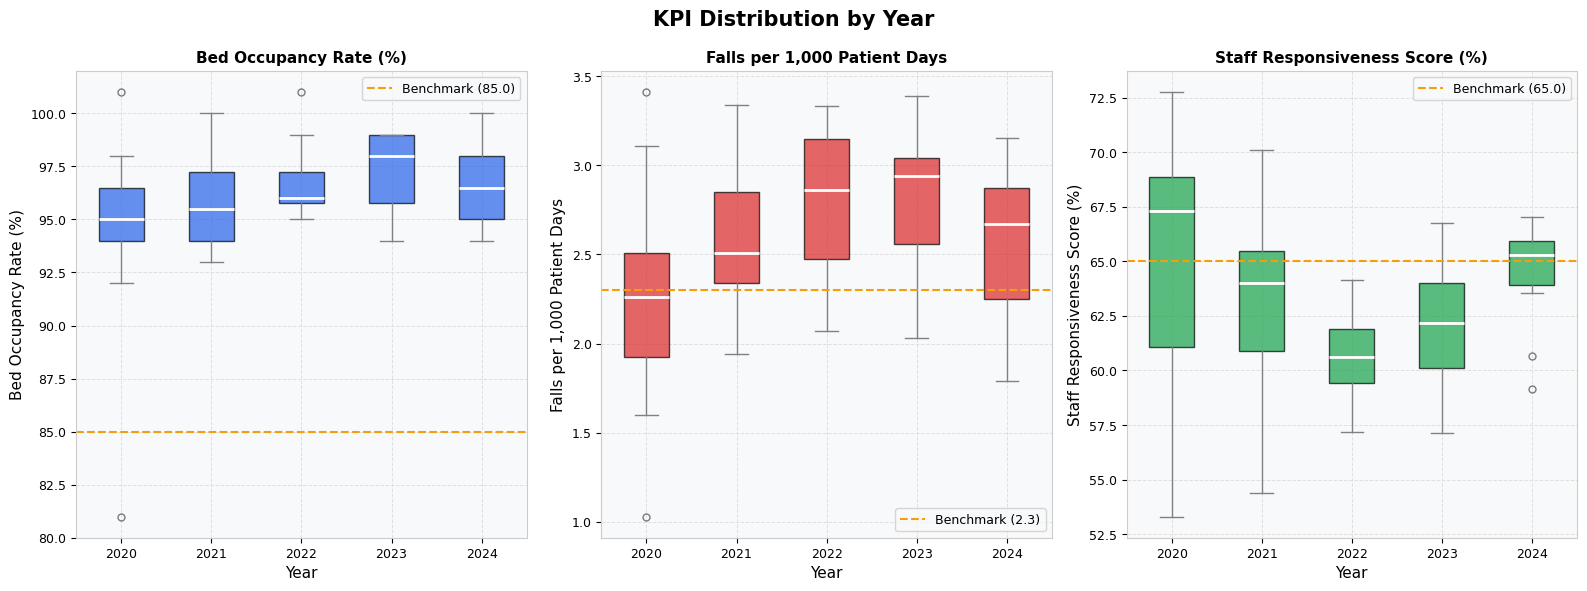

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('KPI Distribution by Year')

box_config = [
    ('occupancy',      'Bed Occupancy Rate (%)',           PALETTE['occupancy'],      BENCHMARKS['occupancy']),
    ('fall_rate',      'Falls per 1,000 Patient Days',     PALETTE['fall_rate'],      BENCHMARKS['fall_rate']),
    ('responsiveness', 'Staff Responsiveness Score (%)',   PALETTE['responsiveness'], BENCHMARKS['responsiveness']),
]

for ax, (col, label, color, bmark) in zip(axes, box_config):
    data_by_year = [df[df['year']==y][col].values for y in sorted(df['year'].unique())]
    bp = ax.boxplot(data_by_year, patch_artist=True, notch=False,
                    medianprops={'color':'white','linewidth':2},
                    whiskerprops={'color':'grey'},
                    capprops={'color':'grey'},
                    flierprops={'marker':'o','color':color,'alpha':0.5,'markersize':5})

    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    ax.axhline(bmark, color=PALETTE['benchmark'], linewidth=1.5, linestyle='--', label=f'Benchmark ({bmark})')
    ax.set_xticklabels(sorted(df['year'].unique()))
    ax.set_xlabel('Year')
    ax.set_ylabel(label)
    ax.set_title(label, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('09_boxplots_by_year.png', dpi=150, bbox_inches='tight')
plt.show()


## 11. Risk Flag Analysis

Which months had multiple KPIs in the danger zone simultaneously? A compound risk flag gives leadership a single alert signal rather than three separate ones.


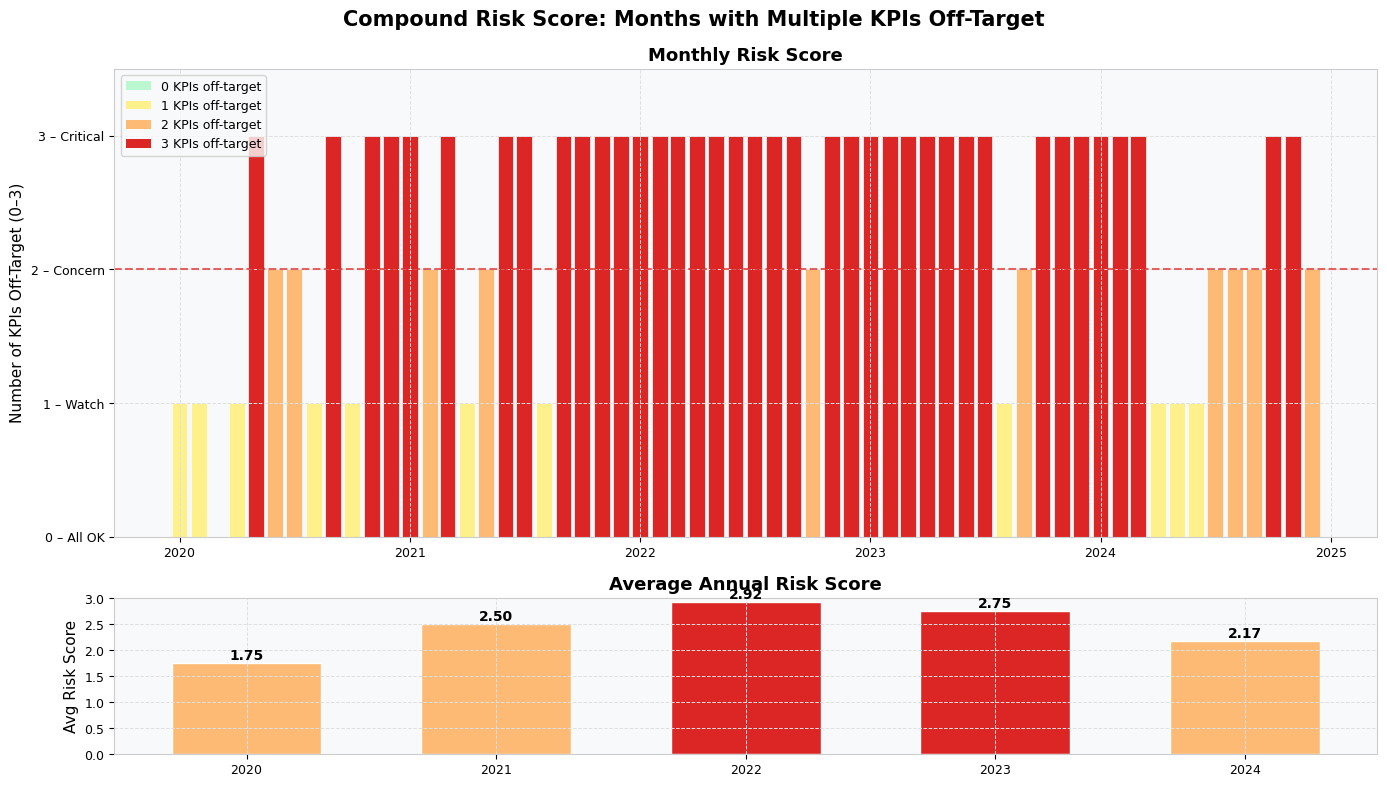


Risk Score Summary:
year  risk_score
2020  0              1
      1              5
      2              2
      3              4
2021  1              2
      2              2
      3              8
2022  2              1
      3             11
2023  1              1
      2              1
      3             10
2024  1              3
      2              4
      3              5

Total red-alert months (all 3 KPIs off-target): 38
Total high-concern months (2+ KPIs off-target) : 48


In [22]:
df['flag_occupancy']     = df['occupancy']      > BENCHMARKS['occupancy']      # above 85 = risk
df['flag_fall']          = df['fall_rate']       > BENCHMARKS['fall_rate']       # above 2.3 = risk
df['flag_responsiveness']= df['responsiveness'] < BENCHMARKS['responsiveness']  # below 65 = risk
df['risk_score']         = df['flag_occupancy'].astype(int) + df['flag_fall'].astype(int) + df['flag_responsiveness'].astype(int)

risk_colors_map = {0: PALETTE['good'], 1: '#FEF08A', 2: '#FDBA74', 3: PALETTE['fall_rate']}

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 8), gridspec_kw={'height_ratios':[3,1]})
fig.suptitle('Compound Risk Score: Months with Multiple KPIs Off-Target')

for _, row in df.iterrows():
    ax_top.bar(row['month'], row['risk_score'], width=25,
               color=risk_colors_map[row['risk_score']], edgecolor='white', linewidth=0.5)

ax_top.axhline(2, color=PALETTE['fall_rate'], linewidth=1.5, linestyle='--', alpha=0.7, label='High-risk threshold (2+ KPIs off-target)')
ax_top.set_ylabel('Number of KPIs Off-Target (0–3)')
ax_top.set_title('Monthly Risk Score')
ax_top.set_ylim(0, 3.5)
ax_top.set_yticks([0,1,2,3])
ax_top.set_yticklabels(['0 – All OK', '1 – Watch', '2 – Concern', '3 – Critical'])
ax_top.legend(fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=f'{k} KPIs off-target') for k, c in risk_colors_map.items()]
ax_top.legend(handles=legend_elements, fontsize=9, loc='upper left')

risk_summary = df.groupby('year')['risk_score'].mean().round(2)
bars = ax_bot.bar(risk_summary.index, risk_summary.values,
                  color=[risk_colors_map[int(round(v))] for v in risk_summary.values],
                  edgecolor='white', linewidth=1, width=0.6)
for bar, val in zip(bars, risk_summary.values):
    ax_bot.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f'{val:.2f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax_bot.set_ylabel('Avg Risk Score')
ax_bot.set_title('Average Annual Risk Score')
ax_bot.set_ylim(0, 3)

plt.tight_layout()
plt.savefig('10_risk_flags.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nRisk Score Summary:")
print(df.groupby('year')['risk_score'].value_counts().sort_index().to_string())
print(f"\nTotal red-alert months (all 3 KPIs off-target): {(df['risk_score']==3).sum()}")
print(f"Total high-concern months (2+ KPIs off-target) : {(df['risk_score']>=2).sum()}")


## 12. Occupancy Deep Dive: The Capacity-Safety Relationship

The strongest predictive signal in this dataset is occupancy driving up fall risk. This section quantifies that relationship precisely using regression, and flags the operational threshold where fall risk becomes critical.


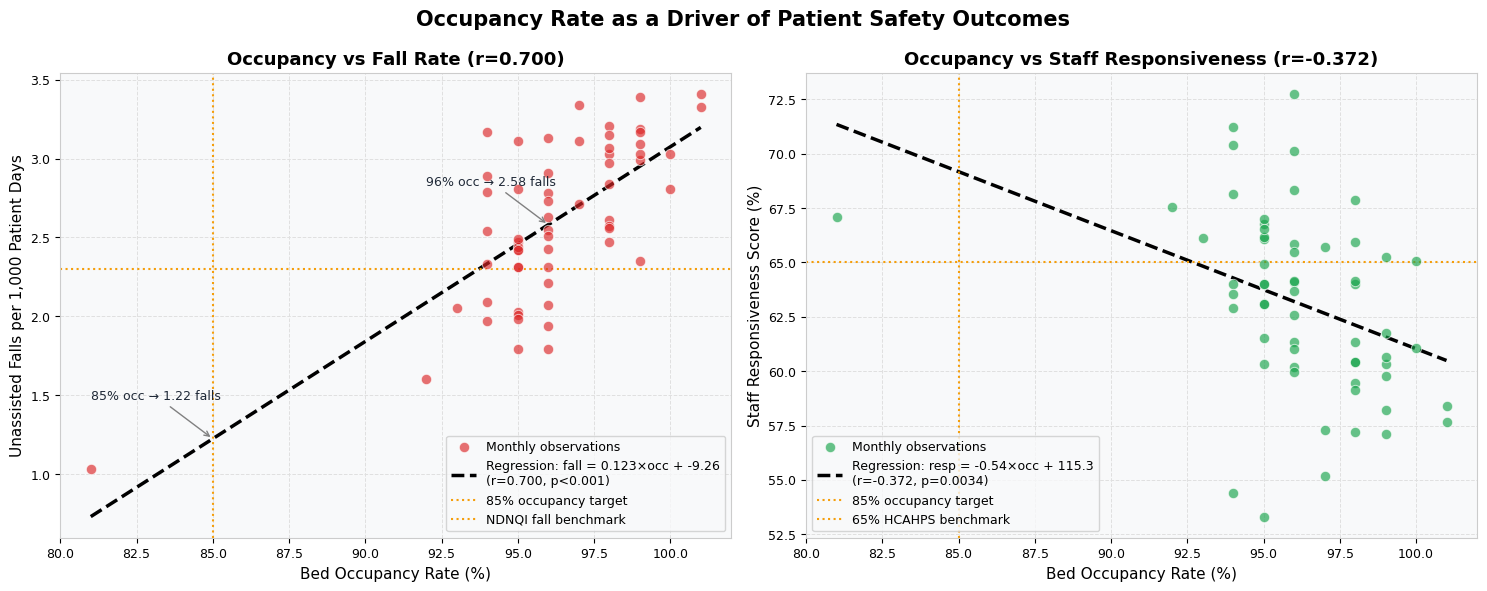


Key finding: Every 1% increase in occupancy rate is associated with:
  + 0.123 additional falls per 1,000 patient days (p<0.001)
  -0.54pp change in staff responsiveness score (p=0.0034)


In [23]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle('Occupancy Rate as a Driver of Patient Safety Outcomes')

# ── Left: Occupancy vs Fall Rate ──────────────────────────────────────────
x = df['occupancy']
y = df['fall_rate']
slope, intercept, r_val, p_val, _ = linregress(x, y)
x_line = np.linspace(x.min(), x.max(), 100)

axes[0].scatter(x, y, c=PALETTE['fall_rate'], alpha=0.65, s=55, edgecolors='white', linewidth=0.7, zorder=3, label='Monthly observations')
axes[0].plot(x_line, slope * x_line + intercept, color='black', linewidth=2.5, linestyle='--',
             label=f'Regression: fall = {slope:.3f}×occ + {intercept:.2f}\n(r={r_val:.3f}, p<0.001)')
axes[0].axvline(BENCHMARKS['occupancy'], color=PALETTE['benchmark'], linewidth=1.5, linestyle=':', label='85% occupancy target')
axes[0].axhline(BENCHMARKS['fall_rate'], color=PALETTE['benchmark'], linewidth=1.5, linestyle=':', label='NDNQI fall benchmark')
axes[0].set_xlabel('Bed Occupancy Rate (%)')
axes[0].set_ylabel('Unassisted Falls per 1,000 Patient Days')
axes[0].set_title(f'Occupancy vs Fall Rate (r={r_val:.3f})')
axes[0].legend(fontsize=9)

# Annotation: expected fall rate at 85% vs 96%
for occ_val in [85, 96]:
    predicted_fall = slope * occ_val + intercept
    axes[0].annotate(f'{occ_val}% occ → {predicted_fall:.2f} falls',
                     xy=(occ_val, predicted_fall), xytext=(occ_val - 4, predicted_fall + 0.25),
                     fontsize=9, color=PALETTE['text_dark'],
                     arrowprops={'arrowstyle':'->', 'color':'grey'})

# ── Right: Occupancy vs Responsiveness ───────────────────────────────────
x2 = df['occupancy']
y2 = df['responsiveness']
s2, i2, r2, p2, _ = linregress(x2, y2)
x_line2 = np.linspace(x2.min(), x2.max(), 100)

axes[1].scatter(x2, y2, c=PALETTE['responsiveness'], alpha=0.65, s=55, edgecolors='white', linewidth=0.7, zorder=3, label='Monthly observations')
axes[1].plot(x_line2, s2 * x_line2 + i2, color='black', linewidth=2.5, linestyle='--',
             label=f'Regression: resp = {s2:.2f}×occ + {i2:.1f}\n(r={r2:.3f}, p={p2:.4f})')
axes[1].axvline(BENCHMARKS['occupancy'], color=PALETTE['benchmark'], linewidth=1.5, linestyle=':', label='85% occupancy target')
axes[1].axhline(BENCHMARKS['responsiveness'], color=PALETTE['benchmark'], linewidth=1.5, linestyle=':', label='65% HCAHPS benchmark')
axes[1].set_xlabel('Bed Occupancy Rate (%)')
axes[1].set_ylabel('Staff Responsiveness Score (%)')
axes[1].set_title(f'Occupancy vs Staff Responsiveness (r={r2:.3f})')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('11_occupancy_deep_dive.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nKey finding: Every 1% increase in occupancy rate is associated with:")
print(f"  + {slope:.3f} additional falls per 1,000 patient days (p<0.001)")
print(f"  {s2:.2f}pp change in staff responsiveness score (p={p2:.4f})")


## 13. Staff Responsiveness: HCAHPS Benchmark Tracker

The HCAHPS benchmark of 65% acts as a regulatory reference point. Tracking how many months fall above and below, and whether the trend in 2024 signals genuine recovery, is directly relevant to leadership decision-making.


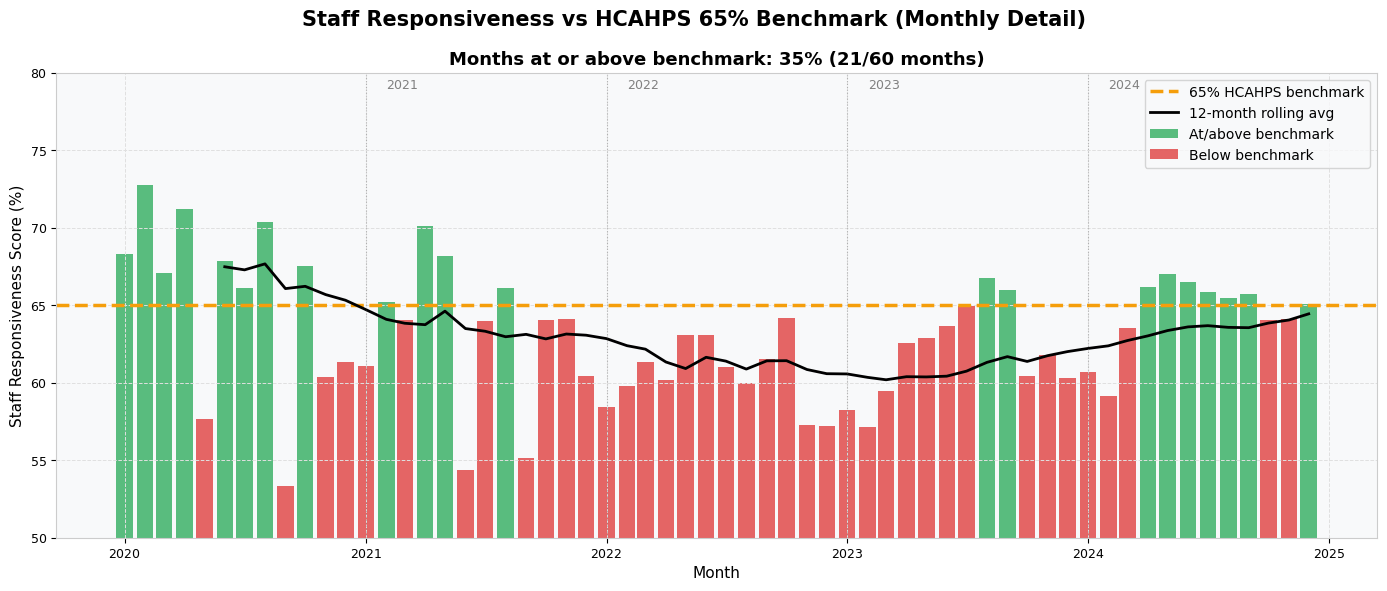


Months above 65% benchmark by year:
year
2020    8
2021    4
2022    0
2023    2
2024    7


In [24]:
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Staff Responsiveness vs HCAHPS 65% Benchmark (Monthly Detail)')

above = df[df['responsiveness'] >= 65]
below = df[df['responsiveness'] < 65]

ax.bar(above['month'], above['responsiveness'], width=25, color=PALETTE['responsiveness'], alpha=0.7, label='At/above benchmark')
ax.bar(below['month'], below['responsiveness'], width=25, color=PALETTE['fall_rate'],     alpha=0.7, label='Below benchmark')
ax.axhline(65, color=PALETTE['benchmark'], linewidth=2.5, linestyle='--', label='65% HCAHPS benchmark')
ax.plot(df['month'], df['resp_roll12'], color='black', linewidth=2, label='12-month rolling avg')

pct_above = (df['responsiveness'] >= 65).mean() * 100
ax.set_ylabel('Staff Responsiveness Score (%)')
ax.set_xlabel('Month')
ax.set_title(f'Months at or above benchmark: {pct_above:.0f}% ({int(pct_above*0.6)}/60 months)')
ax.legend(fontsize=10)
ax.set_ylim(50, 80)

for yr in range(2021, 2025):
    ax.axvline(pd.Timestamp(f'{yr}-01-01'), color='grey', linewidth=0.8, linestyle=':', alpha=0.5)
    ax.text(pd.Timestamp(f'{yr}-02-01'), 79, str(yr), fontsize=9, color='grey')

plt.tight_layout()
plt.savefig('12_responsiveness_tracker.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nMonths above 65% benchmark by year:")
print(df.groupby('year').apply(lambda x: (x['responsiveness']>=65).sum()).rename('months_above_65').to_string())


## 14. Findings and Business Recommendations

### Summary of Key Findings

| Finding | Data Evidence |
|---|---|
| **Occupancy is critically high** | 5-yr avg = 96.2%, vs 85% target. Only 1 month (Mar 2020) ever fell below 85%. |
| **Fall rate worsened 2020–2023** | Rose from 2.25 to 2.82 falls per 1,000 patient days (+25%). Improved in 2024 to 2.57. |
| **Responsiveness declined 2020–2022** | Fell from 65.3% to 60.6%, breaching the HCAHPS benchmark. Partial recovery to 64.5% in 2024. |
| **Occupancy and fall rate are strongly correlated** | Pearson r = 0.700, p < 0.001. Every 1% increase in occupancy adds ~0.12 falls per 1,000 days. |
| **Fall rate and responsiveness are inversely correlated** | r = -0.791, the strongest relationship in the dataset. High fall months are also low responsiveness months. |
| **Sept and June are high-risk months** | Consistently the worst months for fall rate and lowest responsiveness across multiple years. |

### Recommendations for Nursing Leadership

1. **Capacity management is the single highest-leverage intervention.** The data shows that occupancy consistently above 95% creates the conditions for both higher fall rates and lower staff responsiveness. Targeting a ceiling of 90–92% occupancy would be expected to reduce falls by approximately 0.4 per 1,000 days based on the regression coefficient.

2. **Focus Q3 staffing interventions on June and September.** Seasonal analysis shows these are the highest-risk months. Pre-positioning additional bank or agency staff in these months, rather than reacting in-period, is the most cost-effective use of staffing budget.

3. **Treat fall rate as a leading indicator for responsiveness.** Because the two are correlated at r = -0.791, a rising fall rate in any given month is a reliable early warning that responsiveness will also drop. Monitoring fall rate weekly rather than monthly gives a 2–4 week lead time to intervene before HCAHPS scores deteriorate.

4. **Investigate the 2024 recovery trajectory.** The data shows improvement in 2024 across all three KPIs. Understanding what changed operationally in 2024 and codifying it as standard practice is as important as addressing the 2022–2023 deterioration.

5. **Prioritise the responsiveness recovery above the benchmark line.** Currently 35 of 60 months (58%) fall below the 65% HCAHPS benchmark. Reaching 80% of months above benchmark would require a sustained responsiveness score of ~65.5, which the regression predicts is achievable if occupancy is held below 93%.


## Appendix: Full Dataset with Derived Columns

In [25]:
output_cols = ['month', 'year', 'month_name', 'quarter',
               'occupancy', 'fall_rate', 'responsiveness',
               'occ_roll12', 'fall_roll12', 'resp_roll12',
               'flag_occupancy', 'flag_fall', 'flag_responsiveness', 'risk_score']

export = df[output_cols].copy()
export['month'] = export['month'].dt.strftime('%Y-%m')

pd.set_option('display.max_rows', 65)
pd.set_option('display.float_format', '{:.2f}'.format)
print(export.to_string(index=False))
export.to_csv('hospital_kpi_analysis_output.csv', index=False)
print("\nExported to hospital_kpi_analysis_output.csv")


  month  year month_name  quarter  occupancy  fall_rate  responsiveness  occ_roll12  fall_roll12  resp_roll12  flag_occupancy  flag_fall  flag_responsiveness  risk_score
2020-01  2020    January        1      96.00       2.21           68.34         NaN          NaN          NaN            True      False                False           1
2020-02  2020   February        1      96.00       1.79           72.75         NaN          NaN          NaN            True      False                False           1
2020-03  2020      March        1      81.00       1.03           67.07         NaN          NaN          NaN           False      False                False           0
2020-04  2020      April        2      94.00       1.97           71.21         NaN          NaN          NaN            True      False                False           1
2020-05  2020        May        2     101.00       3.41           57.68         NaN          NaN          NaN            True       True              